# CNN based on CIFAR 10 Dataset
> [dataset](http://www.cs.toronto.edu/~kriz/cifar.html)
> Reference to [link](https://blog.csdn.net/yanxueotft/article/details/97977754)

In [1]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
#定义超参数
BATCH_SIZE = 4
EPOCH = 2

#torchvision模块载入CIFAR10数据集
transform = transforms.Compose([transforms.ToTensor(), # 通过transform归一化到[0,1]
                                transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])  # 将[0,1]的RGB归一化为[-1,1]
trainset = torchvision.datasets.CIFAR10(root='./CIFAR10/',train = True,
                                        download=False, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size = BATCH_SIZE,
                                          shuffle = True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./CIFAR10/',train = False,
                                        download=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset,batch_size = BATCH_SIZE,
                                          shuffle = False, num_workers=2)
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')                                          


In [6]:
trainset[0][0].shape

torch.Size([3, 32, 32])

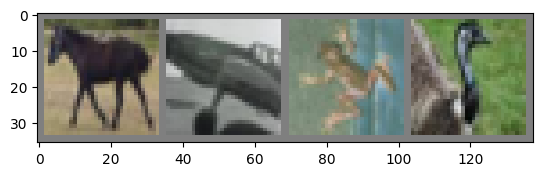

tensor([7, 0, 6, 2])


In [8]:
dataiter = iter(trainloader)
images, labels = dataiter.next()
images_comb = torchvision.utils.make_grid(images)
images_comb_unnor = (images_comb*0.5+0.5).numpy()
plt.imshow(np.transpose(images_comb_unnor, (1, 2, 0)))
plt.show()
print(labels)

In [5]:
# class CNN_NET(torch.nn.Module):
#     def __init__(self):
#         super(CNN_NET,self).__init__()
#         self.conv1 = torch.nn.Conv2d(in_channels = 3,
#                                      out_channels = 64,
#                                      kernel_size = 5,
#                                      stride = 1,
#                                      padding = 0)
#         self.pool = torch.nn.MaxPool2d(kernel_size = 3,
#                                        stride = 2)
#         self.conv2 = torch.nn.Conv2d(64,64,5)
#         self.fc1 = torch.nn.Linear(64*4*4,384)
#         self.fc2 = torch.nn.Linear(384,192)
#         self.fc3 = torch.nn.Linear(192,10)

#     def forward(self,x):
#         x=self.pool(F.relu(self.conv1(x)))
#         x=self.pool(F.relu(self.conv2(x)))
#         x=x.view(-1,64*4*4)
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x

# net = CNN_NET()

In [13]:
class CNN_NET(torch.nn.Module):
    def __init__(self):
        super(CNN_NET,self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels = 3,
                                     out_channels = 64,
                                     kernel_size = 5,
                                     stride = 1,
                                     padding = 2)
        self.pool = torch.nn.MaxPool2d(kernel_size = 2)
        self.conv2 = torch.nn.Conv2d(64,128,5,stride=1,padding=2)
        self.fc1 = torch.nn.Linear(128*8*8,384)
        self.fc2 = torch.nn.Linear(384,192)
        self.fc3 = torch.nn.Linear(192,10)

    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x=x.view(-1,128*8*8)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = CNN_NET()

In [14]:
import torch.optim as optim

optimizer = optim.SGD(net.parameters(),lr=0.001,momentum=0.9)
loss_func =torch.nn.CrossEntropyLoss() # 预测值和真实值的误差计算公式 (交叉熵)

In [15]:
for epoch in range(EPOCH):
    running_loss = 0.0  # 2000批次的average loss
    for step, (b_x,b_y)in enumerate(trainloader):
        outputs = net(b_x) # 喂给 net 训练数据 x, 输出预测值
        loss = loss_func(outputs, b_y) # 计算两者的误差
        optimizer.zero_grad() # 清空上一步的残余更新参数值
        loss.backward() # 误差反向传播, 计算参数更新值
        optimizer.step() # 将参数更新值施加到 net 的 parameters 上
        # 打印状态信息
        running_loss += loss.item()
        if step % 1000 == 999:    # 每2000批次打印一次
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, step + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  1000] loss: 1.074
[1,  2000] loss: 0.901
[1,  3000] loss: 0.820
[1,  4000] loss: 0.773
[1,  5000] loss: 0.736
[1,  6000] loss: 0.718
[1,  7000] loss: 0.682
[1,  8000] loss: 0.653
[1,  9000] loss: 0.620
[1, 10000] loss: 0.617
[1, 11000] loss: 0.590
[1, 12000] loss: 0.569
[2,  1000] loss: 0.521
[2,  2000] loss: 0.519
[2,  3000] loss: 0.506
[2,  4000] loss: 0.483
[2,  5000] loss: 0.490
[2,  6000] loss: 0.478
[2,  7000] loss: 0.466
[2,  8000] loss: 0.469
[2,  9000] loss: 0.474
[2, 10000] loss: 0.464
[2, 11000] loss: 0.437
[2, 12000] loss: 0.428
Finished Training


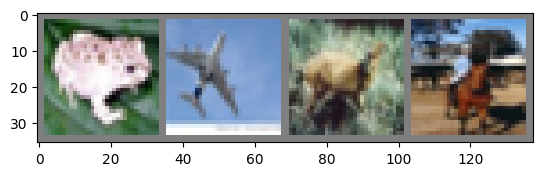

In [16]:
dataiter = iter(trainloader)
images, labels = dataiter.next()
images_comb = torchvision.utils.make_grid(images)
images_comb_unnor = (images_comb*0.5+0.5).numpy()
plt.imshow(np.transpose(images_comb_unnor, (1, 2, 0)))
plt.show()

predicts=net.forward(images)

In [17]:
correct = 0
total = 0
with torch.no_grad():
    #不计算梯度，节省时间
    for (images,labels) in testloader:
        outputs = net(images)
        numbers,predicted = torch.max(outputs.data,1)
        total +=labels.size(0)
        correct+=(predicted==labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 68 %
